In [35]:
# Install required packages
!pip -q install duckdb pandas matplotlib


In [36]:
# Import necessary libraries
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect()  # in-memory DB


In [37]:
# Replace paths with your files
orders = pd.read_csv("/Users/dineshkumarmuthusamy/Desktop/discount/data_row/orders.csv")
order_items = pd.read_csv("/Users/dineshkumarmuthusamy/Desktop/discount/data_row/order_items.csv")

con.register("orders", orders)
con.register("order_items", order_items)


In [38]:
# SQL query to calculate daily order metrics
query = """
WITH per_order AS (
  SELECT
    o.order_id,
    DATE(o.order_date) AS order_date,
    ROUND(SUM(COALESCE(oi.qty, 0) * COALESCE(oi.unit_price_gbp, 0)), 2) AS gross_before_discount_gbp,
    ROUND(SUM(COALESCE(oi.qty, 0) * COALESCE(oi.discount_gbp, 0)), 2) AS total_discount_gbp,
    ROUND(
      SUM(
        (COALESCE(oi.qty, 0) * COALESCE(oi.unit_price_gbp, 0))
        - (COALESCE(oi.qty, 0) * COALESCE(oi.discount_gbp, 0))
      ), 2
    ) AS paid_after_discount_gbp
  FROM orders o
  JOIN order_items oi
    ON oi.order_id = o.order_id
  WHERE COALESCE(o.order_status, '') <> 'CANCELLED'
    AND o.order_date IS NOT NULL
  GROUP BY o.order_id, DATE(o.order_date)
)
SELECT
  order_date,
  COUNT(*) AS orders_count,
  ROUND(SUM(gross_before_discount_gbp), 2) AS gross_before_discount_gbp,
  ROUND(SUM(total_discount_gbp), 2) AS total_discount_gbp,
  ROUND(SUM(paid_after_discount_gbp), 2) AS net_revenue_gbp,
  ROUND(100.0 * SUM(total_discount_gbp) / NULLIF(SUM(gross_before_discount_gbp), 0), 1) AS discount_rate_pct
FROM per_order
GROUP BY order_date
ORDER BY order_date ASC;
"""
df = con.execute(query).df()
df.head(8)


,order_date,orders_count,gross_before_discount_gbp,total_discount_gbp,net_revenue_gbp,discount_rate_pct
0,2025-11-01,1,104.98,10.0,94.98,9.5
1,2025-11-02,1,24.97,2.0,22.97,8.0
2,2025-11-03,1,59.98,0.0,59.98,0.0
3,2025-11-04,1,19.48,0.0,19.48,0.0
4,2025-11-05,1,79.99,0.0,79.99,0.0
5,2025-11-06,1,34.98,5.0,29.98,14.3
6,2025-11-07,1,29.98,0.0,29.98,0.0
7,2025-11-08,1,24.99,0.0,24.99,0.0


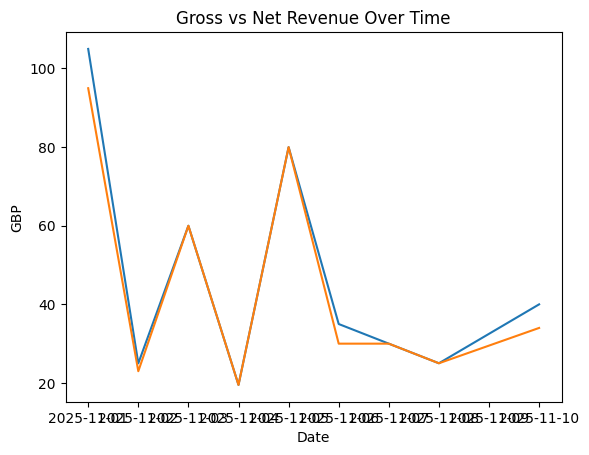

In [39]:
# Plot Gross vs Net Revenue Over Time
df["order_date"] = pd.to_datetime(df["order_date"])

plt.figure()
plt.plot(df["order_date"], df["gross_before_discount_gbp"])
plt.plot(df["order_date"], df["net_revenue_gbp"])
plt.title("Gross vs Net Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("GBP")
plt.show()


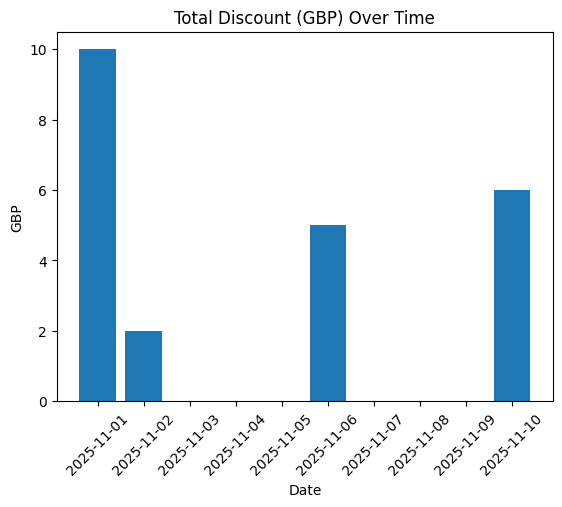

In [40]:
# Plot Discount Rate Over Time
plt.figure()
plt.bar(df["order_date"], df["total_discount_gbp"])
plt.title("Total Discount (GBP) Over Time")
plt.xlabel("Date")
plt.ylabel("GBP")
plt.xticks(rotation=45)
plt.show()


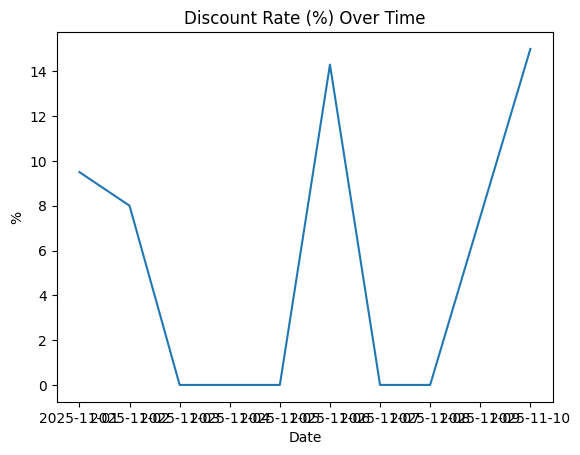

In [41]:
# Plot Discount Rate (%) Over Time
plt.figure()
plt.plot(df["order_date"], df["discount_rate_pct"])
plt.title("Discount Rate (%) Over Time")
plt.xlabel("Date")
plt.ylabel("%")
plt.show()


In [42]:
# Export the results to a CSV file
df.to_csv("daily_discount_metrics.csv", index=False)
